# Classification
---

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Данные

Набор данных по диагностике диабета.

Этот набор данных содержит 9538 медицинских записей , связанных с диагностикой диабета и факторами риска. Он включает различные параметры здоровья, привычки образа жизни и генетические предрасположенности, которые способствуют риску диабета. Данные структурированы с реалистичными распределениями, что делает их ценными для медицинских исследований, статистического анализа и приложений машинного обучения.

---
Описание столбцов:

- Age: The age of the individual (18-90 years).
- Pregnancies: Number of times the patient has been pregnant.
- BMI (Body Mass Index): A measure of body fat based on height and weight (kg/m²).
- Glucose: Blood glucose concentration (mg/dL), a key diabetes indicator.
- BloodPressure: Systolic blood pressure (mmHg), higher levels may indicate hypertension.
- HbA1c: Hemoglobin A1c level (%), representing average blood sugar over months.
- LDL (Low-Density Lipoprotein): "Bad" cholesterol level (mg/dL).
- HDL (High-Density Lipoprotein): "Good" cholesterol level (mg/dL).
- Triglycerides: Fat levels in the blood (mg/dL), high values increase diabetes risk.
- WaistCircumference: Waist measurement (cm), an indicator of central obesity.
- HipCircumference: Hip measurement (cm), used to calculate WHR.
- WHR (Waist-to-Hip Ratio): Waist circumference divided by hip circumference.
- FamilyHistory: Indicates if the individual has a family history of diabetes (1 = Yes, 0 = No).
- DietType: Dietary habits (0 = Unbalanced, 1 = Balanced, 2 = Vegan/Vegetarian).
- Hypertension: Presence of high blood pressure (1 = Yes, 0 = No).
- MedicationUse: Indicates if the individual is taking medication (1 = Yes, 0 = No).
- Outcome: Diabetes diagnosis result (1 = Diabetes, 0 = No Diabetes).

---
Этот набор данных полезен для изучения взаимосвязей между образом жизни, генетическими факторами и риском развития диабета, предоставляя ценную информацию для прогностического моделирования и аналитики здоровья.

In [77]:
df = pd.read_csv('diabetes_dataset.csv')
df.sample(10)

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
9093,56,11,27.75,125.8,82.0,5.0,108.6,50.8,126.1,98.6,107.1,0.92,1,0,0,0,1
1681,32,9,25.44,76.1,80.0,4.0,132.7,66.8,187.1,99.6,97.8,1.02,0,0,0,0,0
7009,24,4,28.38,76.2,91.0,4.2,139.5,28.8,102.1,83.4,116.3,0.72,0,0,0,0,0
4496,76,13,38.41,135.7,99.0,5.7,101.5,57.1,167.8,103.8,114.3,0.91,0,0,0,1,0
6943,28,3,17.25,82.1,71.0,4.0,44.0,33.5,88.7,62.7,76.1,0.82,0,0,0,0,0
5576,26,14,29.73,104.4,89.0,4.3,64.2,52.1,148.9,87.8,110.1,0.80,0,0,0,0,0
5656,57,10,22.65,95.0,65.0,4.0,102.9,28.5,165.3,73.8,86.3,0.86,0,0,0,0,0
9262,27,12,21.89,82.9,72.0,4.6,71.9,40.7,103.2,69.1,91.2,0.76,1,0,0,0,1
2129,67,5,34.92,133.0,113.0,5.0,99.0,42.5,156.6,107.4,118.9,0.90,0,0,0,1,0
6606,30,8,17.38,71.2,60.0,4.3,94.2,41.2,198.5,93.2,101.4,0.92,1,0,0,0,1


Ознакомьтесь с данными, проверьте их на наличие ошибок, пропусков и прочих вещей, которые могут осложнить дальнейшую работу. Ознакомьтесь с типами данных в таблице.

In [78]:
display(df.isnull().sum())
display(df.describe())

,0
Age,0
Pregnancies,0
BMI,0
Glucose,0
BloodPressure,0
HbA1c,0
LDL,0
HDL,0
Triglycerides,0
WaistCircumference,0


,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
count,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000,9538.000000
mean,53.577584,7.986161,27.052364,106.104183,84.475781,4.650661,100.133456,49.953418,151.147746,93.951678,103.060621,0.917400,0.302474,0.486161,0.001048,0.405012,0.344097
std,20.764651,4.933469,5.927955,21.918590,14.123480,0.476395,29.911910,15.242194,48.951627,15.594468,13.438827,0.140828,0.459354,0.661139,0.032364,0.490920,0.475098
min,18.000000,0.000000,15.000000,50.000000,60.000000,4.000000,-12.000000,-9.200000,50.000000,40.300000,54.800000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,4.000000,22.870000,91.000000,74.000000,4.300000,80.100000,39.700000,117.200000,83.400000,94.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,8.000000,27.050000,106.000000,84.000000,4.600000,99.900000,50.200000,150.550000,93.800000,103.200000,0.910000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,12.000000,31.180000,121.000000,94.000000,5.000000,120.200000,60.200000,185.100000,104.600000,112.100000,1.010000,1.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,16.000000,49.660000,207.200000,138.000000,6.900000,202.200000,107.800000,345.800000,163.000000,156.600000,1.490000,1.000000,2.000000,1.000000,1.000000,1.000000


## Выборка данных

В разделении данных помогает замечательна функция `train_test_split` из библиотеки `scikit-learn`. Именно этой библиотекой мы в основном будем пользоваться в дальнейшем. Напоминаю, если у вас нет библиотеки, её легко установить через `pip` даже из ячейки ноутбука.

In [79]:
# !pip install scikit-learn

In [80]:
from sklearn.model_selection import train_test_split

Теперь можем использовать эту функцию для разделения данных. Функция принимает на вход два набора данных (пожаем один с признаками, другой с целевым признаком), аргумент `test_size` позволяет указать долю данных, которую нужно отделить в тестовый набор. Функция автоматически случаным образом разделит датасеты в указанном соотношении, при этом в тестовую часть попадут соответствующие строки из обоих наборов данных.

Также указывается аргумент `random_state`, он не обязателен, но рекомендуется его указывать. Это фиксация сида для генерации рандомных чисел. Таким образом, указывая одно и то же число в этом аргументе, вы получите одно и то же разбиение на выборки. Этот аргумент позволяет сделать ваши манипуляции воспроизводимыми.

Функция возвращает четыре датасета, по два для каждого из переданных, при этом в каждой паре сначала идет обучающая выборка, затем тестовая. Обратите внимание, как мы сохраняем резульатат. Здесь "x" - признаки, "y" - целевой признак.

In [81]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['Outcome'], axis=1), df['Outcome'], test_size=0.25, random_state=42)

Сравните размеры датасетов, убедитесь, что в тестовой выборке нужное нам количество данных. Сравните индексы датасетов с признаками и целевым признаком, чтобы убедиться, что они совпадают.

In [82]:
print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

x_train: (7153, 16)
y_train: (7153,)
x_test: (2385, 16)
y_test: (2385,)


## kNN

In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
knn = KNeighborsClassifier(n_neighbors=10)

In [85]:
knn_model = knn.fit(x_train, y_train)

In [86]:
knn_predictions = knn.predict(x_test.values)
knn_predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 0])

In [87]:
from sklearn.metrics import accuracy_score

In [88]:
accuracy = accuracy_score(y_test, knn_predictions)
print(f'Accuracy: {accuracy}')

Accuracy: 0.6737945492662474


Матрица ошибок

---
|           | Predicted: 0 | Predicted:1 |
|-----------|:------------:|:-----------:|
| Actual: 0 | TN           | FP          |
| Actual: 1 | FN           | TP          |

In [89]:
from sklearn.metrics import confusion_matrix

In [90]:
confusion_matrix(y_test, knn_predictions)

array([[1480,  102],
       [ 676,  127]])

Матрица ошибок хороша, но можно ли сделать её легче для восприятия? Попробуйте сделать тепловую карту.

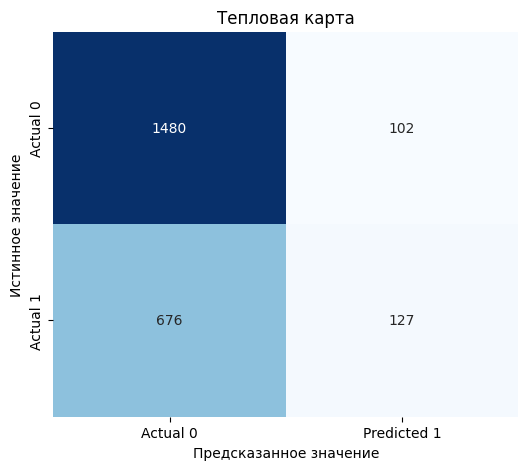

In [91]:
cm = confusion_matrix(y_test, knn_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Actual 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Предсказанное значение')
plt.ylabel('Истинное значение')
plt.title('Тепловая карта')
plt.show()

Продолжим изучение метрик. Что мы можем получить ещё из матрицы ошибок? Два важных показателя.

---

$Precision = \frac{TP}{TP+FP}$

Точность определяет, как много отрицательных ответов нашла модель, пока искала положительные. Чем больше отрицательных, тем ниже точность.

---

$Recall = \frac{TP}{TP+FN}$

Полнота выявляет, какую долю положительных среди всех ответов выделила модель. Обычно они на вес золота, и важно понимать, как хорошо модель их находит.

In [92]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [93]:
precision = precision_score(y_test, knn_predictions)
recall = recall_score(y_test, knn_predictions)
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Precision: 0.5545851528384279
Recall: 0.1581569115815691


F1-мера - среднее гармоническое точности и полноты.

In [94]:
f1 = f1_score(y_test, knn_predictions)
print(f'F1: {f1}')

F1: 0.24612403100775193


/tmp/ipykernel_1860/1478937934.py:9: RuntimeWarning: invalid value encountered in divide
  z = 2*X*Y/(X+Y)


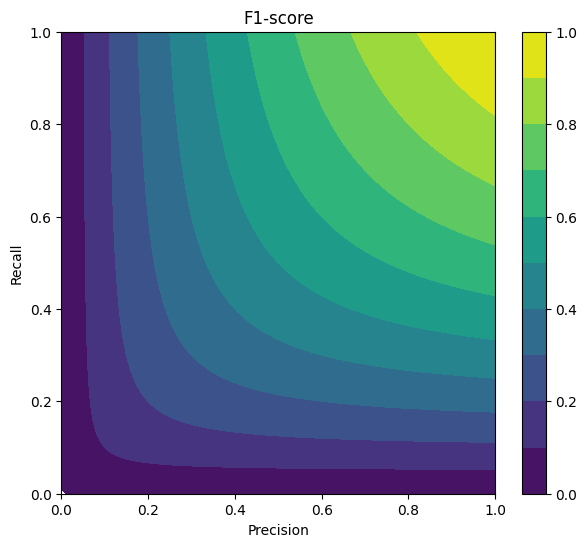

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker

x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)
z = 2*X*Y/(X+Y)

fig, ax = plt.subplots(figsize=(7,6))
cs = ax.contourf(X, Y, z, locator=ticker.LinearLocator())
cbar = fig.colorbar(cs)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('F1-score');

## Нормализация

In [96]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [97]:
scaler = StandardScaler()

In [98]:
scaler.fit_transform(x_train)

array([[-0.88697085,  0.4037797 ,  1.12362248, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [-0.93494042,  0.80894716,  0.75502011, ...,  0.80315257,
        -0.02897435, -0.81954393],
       [ 0.02445086, -0.81172266, -0.4150388 , ...,  0.80315257,
        -0.02897435, -0.81954393],
       ...,
       [ 0.60008563,  1.61928207, -1.95370008, ...,  0.80315257,
        -0.02897435,  1.22019084],
       [ 0.98384215, -1.01430639, -0.89185471, ...,  2.33800439,
        -0.02897435,  1.22019084],
       [ 0.69602476, -0.20397148, -0.98992323, ..., -0.73169924,
        -0.02897435,  1.22019084]])

In [99]:
scaler.transform(x_test)

array([[ 1.70338561,  0.4037797 ,  1.00526392, ..., -0.73169924,
        -0.02897435,  1.22019084],
       [ 0.02445086,  1.21411461, -0.99499574, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [-0.59915347,  1.61928207,  0.30018507, ...,  0.80315257,
        -0.02897435, -0.81954393],
       ...,
       [-1.07884911, -0.20397148,  0.98497388, ...,  2.33800439,
        -0.02897435, -0.81954393],
       [-0.59915347, -1.62205757, -1.13026267, ..., -0.73169924,
        -0.02897435, -0.81954393],
       [ 0.07242043,  0.60636343,  1.42120971, ..., -0.73169924,
        -0.02897435, -0.81954393]])

In [100]:
scaler_2 = MinMaxScaler()

In [101]:
scaler_2.fit_transform(x_train)

array([[0.23943662, 0.625     , 0.56223692, ..., 0.        , 0.        ,
        0.        ],
       [0.22535211, 0.75      , 0.49669272, ..., 0.5       , 0.        ,
        0.        ],
       [0.50704225, 0.25      , 0.288635  , ..., 0.5       , 0.        ,
        0.        ],
       ...,
       [0.67605634, 1.        , 0.01503307, ..., 0.5       , 0.        ,
        1.        ],
       [0.78873239, 0.1875    , 0.20384847, ..., 1.        , 0.        ,
        1.        ],
       [0.70422535, 0.4375    , 0.1864101 , ..., 0.        , 0.        ,
        1.        ]])

In [102]:
scaler_2.transform(x_test)

array([[1.        , 0.625     , 0.54119062, ..., 0.        , 0.        ,
        1.        ],
       [0.50704225, 0.875     , 0.18550812, ..., 0.        , 0.        ,
        0.        ],
       [0.32394366, 1.        , 0.41581479, ..., 0.5       , 0.        ,
        0.        ],
       ...,
       [0.18309859, 0.4375    , 0.53758268, ..., 1.        , 0.        ,
        0.        ],
       [0.32394366, 0.        , 0.1614552 , ..., 0.        , 0.        ,
        0.        ],
       [0.52112676, 0.6875    , 0.61515334, ..., 0.        , 0.        ,
        0.        ]])

## Дисбаланс

Посмотрим на объемы данных в наших классах. Напишите код. чтобы сравнить их размеры:

In [103]:
display(df['Outcome'].value_counts())
display(y_train.value_counts())
display(y_test.value_counts())

,count
Outcome,
0,6256
1,3282


,count
Outcome,
0,4674
1,2479


,count
Outcome,
0,1582
1,803


Upsampling and Downsampling

Синтез

In [104]:
df.columns

Index(['Age', 'Pregnancies', 'BMI', 'Glucose', 'BloodPressure', 'HbA1c', 'LDL',
       'HDL', 'Triglycerides', 'WaistCircumference', 'HipCircumference', 'WHR',
       'FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse',
       'Outcome'],
      dtype='object')

In [105]:
# x_test = x_test.drop(['FamilyHistory'], axis=1)

## Дерево решений

In [106]:
from sklearn.tree import DecisionTreeClassifier

In [107]:
clf = DecisionTreeClassifier(random_state=42)

In [108]:
clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [109]:
pred = clf.predict(x_test)

In [110]:
accuracy_score(y_test, pred)

1.0

In [111]:
from sklearn import tree

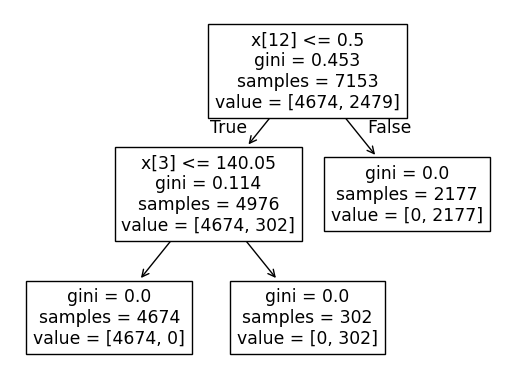

In [112]:
tree.plot_tree(clf);

## Кросс-валидация

In [113]:
from sklearn.model_selection import cross_val_score

In [114]:
cross_val_score(clf, df.drop(['Outcome'], axis=1), df['Outcome'], cv=5).mean()

np.float64(1.0)